# Langevin GLV at the critical point — MSB observables

A multiplicative-noise GLV on a **dense heavy-tailed power-law graph**, at the cooperative critical
point. For a power-law degree law the critical mean interaction collapses to $\mu_c\!\to\!0$
(both theoretically, $\mu_c=1/\langle g^2\rangle$ with $g=k/C$ and $\langle g^2\rangle\!\gg\!1$ for a
heavy tail, and empirically — see `annealed_power_law_glv.ipynb`), so we operate at $\mu=0$,
$\sigma_{\rm mat}=0.2$, $\alpha=1.5$.

The mean-field term drops at $\mu=0$, leaving $W=A\,(\sigma/\sqrt C)\,B$ with $A$ the annealed
(Chung--Lu) adjacency and $B$ a frozen symmetric disorder draw. We add an explicit multiplicative
(Langevin) noise and integrate the **relative composition** $y$ (simplex-renormalized, bounded),
reading MSB off the relative size $S_i=N y_i$. Euler--Maruyama in rescaled time $\tau$:
$$d\ln y_i=\big(F_i-\phi-y_i+\textstyle\sum_j y_j^2\big)\,d\tau+s\,dW_i,\qquad F=Wy,\ \phi=y^\top F,$$
renormalizing $y\leftarrow y/\sum y$ each step. Growth $g_i=\Delta\ln S_i$, volatility
$\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$, swept over the noise strength $s$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

import glv
glv.apply_style()

N          = 400
ALPHA      = 1.5          # power-law hidden-degree tail: k = k_min * U^(-1/alpha)
KMIN       = 2.0          # hidden-degree lower cutoff (no upper cap -> heavy tail)
SIGMA_MAT  = 0.2          # interaction-matrix disorder
MU         = 0.0          # mean interaction = mu_c (-> 0 for the heavy-tail power law)
S_GRID     = np.array([0.05, 0.1, 0.2, 0.3])   # Langevin noise strengths
dt         = 0.02         # Euler-Maruyama step in rescaled tau
tmax       = 600.0        # total rescaled-time horizon
burn       = 0.3          # discard first fraction (reach stochastic steady state)
sample_dt  = 1.0          # record every sample_dt in tau
n_runs     = 6            # graph realizations pooled per s
FLOOR      = 1e-6         # live-size mask on mean relative size
RES        = "langevin_glv_critical_results.npz"
print(f"Langevin GLV @ mu_c=0 | power-law alpha={ALPHA}, k_min={KMIN}, sigma_mat={SIGMA_MAT} "
      f"| noise s in {list(S_GRID)} | dt={dt}, tmax={tmax:g} | N={N} x {n_runs} runs/s")

Langevin GLV @ mu_c=0 | power-law alpha=1.5, k_min=2.0, sigma_mat=0.2 | noise s in [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3)] | dt=0.02, tmax=600 | N=400 x 6 runs/s


In [2]:
# Inline dense annealed (Chung-Lu) heavy-tailed power-law graph + interaction matrix.
def sym_noise(N, rng):
    G = rng.standard_normal((N, N))
    B = (G + G.T) / np.sqrt(2.0)
    B[np.diag_indices(N)] = rng.standard_normal(N)   # keep diagonal unit-variance
    return B

def build_power_graph(N, alpha, k_min, rng):
    U = rng.uniform(0.0, 1.0, size=N)
    k = k_min * U ** (-1.0 / alpha)                  # heavy-tailed hidden degrees (no cap)
    C = float(k.mean())
    outer = np.outer(k, k)
    P = outer / (outer + N * C)                      # Chung-Lu connection probabilities
    A = P + np.sqrt(P * (1.0 - P)) * sym_noise(N, rng)
    A[np.diag_indices(N)] = 0.0                       # no self-loops
    return k, C, A

# W = A*(mu/C + sigma/sqrt(C) B); at mu=0 the mean-field term drops.
def build_W(A, C, mu, sigma, B):
    return A * ((mu / C) + (sigma / np.sqrt(C)) * B)

In [3]:
# EM on the relative composition y (sum y = 1), bounded by construction.
# d ln y = (F - phi - y + sum y^2) dtau + s dW ; renormalize y each step.
def integrate_relative(W, s, seed):
    rng = np.random.default_rng(seed)
    y = np.full(N, 1.0 / N, dtype=np.float64)
    nstep = int(tmax / dt)
    stride = max(int(sample_dt / dt), 1)
    sdt = s * np.sqrt(dt)
    rec, rect = [], []
    for n in range(nstep):
        F = W @ y
        phi = float(y @ F)
        sq = float(y @ y)
        u = np.log(y) + (F - phi - y + sq) * dt + sdt * rng.standard_normal(N)
        u -= u.max()                       # stabilize exp
        y = np.exp(u)
        y /= y.sum()                       # renormalize to simplex
        assert np.isfinite(y).all(), f"non-finite state at step {n}"
        if n % stride == 0:
            rec.append(N * y); rect.append(n * dt)
    S = np.array(rec, dtype=np.float64).T  # (N, T)
    assert np.allclose(S.sum(axis=0), N, rtol=1e-6), "columns of S must sum to N"
    return np.array(rect), S

In [4]:
# Sweep noise s; per realization build a fresh graph + disorder, integrate, pool observables.
def observables(S, t):
    Sl = S[:, t >= burn * tmax]
    log_S = np.log(np.maximum(Sl, 1e-15))
    g = np.diff(log_S, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    vol = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    return Sl.mean(axis=1), vol, g.ravel()

if os.path.exists(RES):
    d = np.load(RES, allow_pickle=True)
    by_s = d["by_s"].item()
    print(f"loaded cache {RES}")
else:
    by_s = {float(s): {"avg": [], "vol": [], "g": [], "kbar": []} for s in S_GRID}
    for i, s in enumerate(S_GRID):
        for r in range(n_runs):
            seed = 7000 + 13 * i + r
            rng = np.random.default_rng(seed)
            k, C, A = build_power_graph(N, ALPHA, KMIN, rng)
            B = sym_noise(N, rng)
            W = build_W(A, C, MU, SIGMA_MAT, B)
            t, S = integrate_relative(W, float(s), seed)
            a, v, g = observables(S, t)
            dd = by_s[float(s)]
            dd["avg"].append(a); dd["vol"].append(v); dd["g"].append(g); dd["kbar"].append(C)
            print(f"  s={s:g} run {r}: <k>={C:.2f}, <S>max={a.max():.2f}, vol[med]={np.median(v):.3f}")
    for s in by_s:
        for key in ("avg", "vol", "g"):
            by_s[s][key] = np.concatenate(by_s[s][key]) if by_s[s][key] else np.array([])
    np.savez(RES, by_s=np.array(by_s, dtype=object))
    print(f"saved {RES}")

  s=0.05 run 0: <k>=5.12, <S>max=2.86, vol[med]=0.050


  s=0.05 run 1: <k>=6.12, <S>max=3.52, vol[med]=0.050


  s=0.05 run 2: <k>=5.25, <S>max=2.92, vol[med]=0.050


  s=0.05 run 3: <k>=6.02, <S>max=2.93, vol[med]=0.050


  s=0.05 run 4: <k>=5.83, <S>max=3.89, vol[med]=0.050


...

  s=0.3 run 1: <k>=6.04, <S>max=13.87, vol[med]=0.304


  s=0.3 run 2: <k>=5.47, <S>max=11.33, vol[med]=0.305


  s=0.3 run 3: <k>=4.88, <S>max=11.13, vol[med]=0.305


  s=0.3 run 4: <k>=7.66, <S>max=12.10, vol[med]=0.306


  s=0.3 run 5: <k>=6.83, <S>max=14.92, vol[med]=0.304
saved langevin_glv_critical_results.npz


In [5]:
# Equal-count binned median (log-log) and two-branch power-law slopes.
def vbin(x, y, nb=22):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]), np.array([np.median(yp[p]) for p in parts]))

def two_slopes(x, y):
    bx, by = vbin(x, y)
    j = int(np.argmin(by))
    if j < 1 or j > len(bx) - 2:
        sl = np.polyfit(np.log10(bx), np.log10(by), 1)[0]
        return bx[j], sl, sl
    lo = np.polyfit(np.log10(bx[:j + 1]), np.log10(by[:j + 1]), 1)[0]
    hi = np.polyfit(np.log10(bx[j:]), np.log10(by[j:]), 1)[0]
    return bx[j], lo, hi

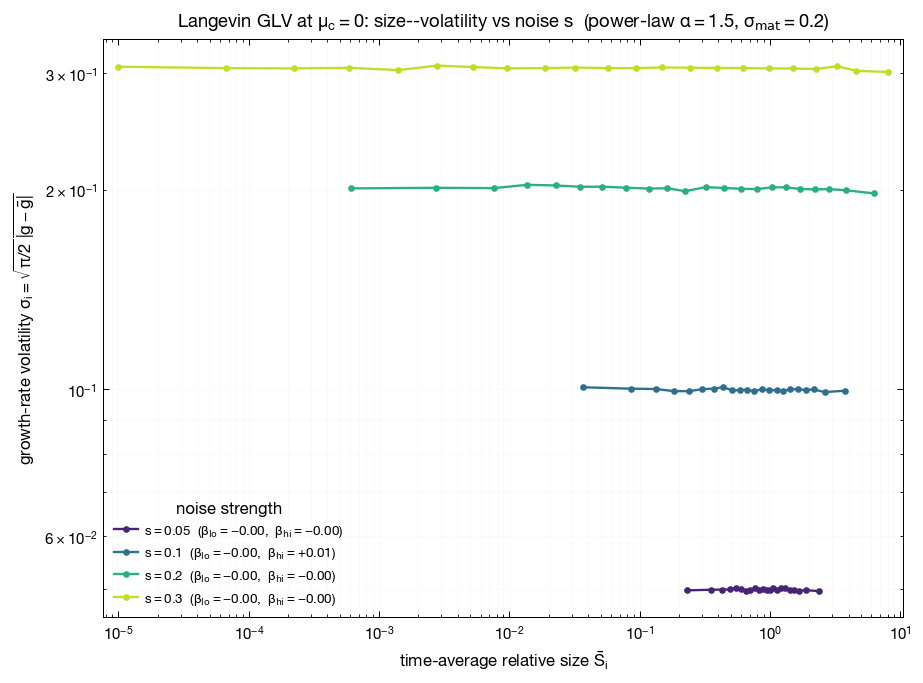

In [6]:
# Plot 1: size-volatility relation, one V-curve per noise strength s.
fig, ax = plt.subplots(figsize=(7.8, 5.8))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(S_GRID)))
for s, col in zip(sorted(by_s), cmap):
    b = by_s[s]
    if b["avg"].size == 0:
        continue
    live = (b["avg"] > FLOOR) & (b["vol"] > 0) & np.isfinite(b["vol"])
    if live.sum() < 50:
        continue
    bx, by = vbin(b["avg"][live], b["vol"][live])
    _, blo, bhi = two_slopes(b["avg"][live], b["vol"][live])
    ax.loglog(bx, by, "o-", ms=4, color=col,
              label=rf"$s={s:g}$  ($\beta_{{\rm lo}}={blo:+.2f},\ \beta_{{\rm hi}}={bhi:+.2f}$)")
ax.set(xlabel=r"time-average relative size $\bar S_i$",
       ylabel=r"growth-rate volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$",
       title=rf"Langevin GLV at $\mu_c=0$: size--volatility vs noise $s$  "
             rf"(power-law $\alpha={ALPHA}$, $\sigma_{{\rm mat}}={SIGMA_MAT}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend(fontsize=8, title="noise strength")
plt.tight_layout()
plt.savefig("langevin_glv_critical_volatility_size.png", dpi=120)
plt.show()

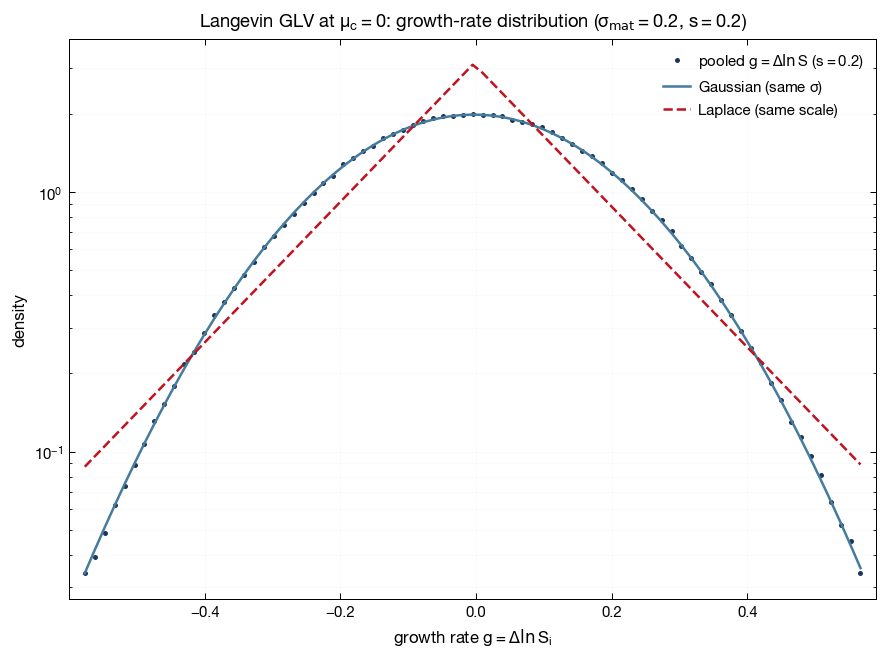

s=0.2: mean=-0.0033, median=-0.0034, std=0.2010, skew=-0.00, excess_kurtosis=+0.00


In [7]:
# Plot 2: pooled growth-rate distribution at a representative s.
s_show = 0.2 if 0.2 in by_s else sorted(by_s)[len(by_s) // 2]
g = by_s[s_show]["g"]; g = g[np.isfinite(g)]
mu_g, sd_g, med_g = g.mean(), g.std(), np.median(g)
b_lap = np.mean(np.abs(g - med_g))
lo, hi = np.percentile(g, [0.2, 99.8])
edges = np.linspace(lo, hi, 80); centers = 0.5 * (edges[:-1] + edges[1:])
dens, _ = np.histogram(g, bins=edges, density=True)
gauss = np.exp(-0.5 * ((centers - mu_g) / sd_g) ** 2) / (sd_g * np.sqrt(2 * np.pi))
lap = np.exp(-np.abs(centers - med_g) / b_lap) / (2 * b_lap)
fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.semilogy(centers, np.where(dens > 0, dens, np.nan), "o", ms=3, color="#1d3557",
            label=rf"pooled $g=\Delta\ln S$ ($s={s_show:g}$)")
ax.semilogy(centers, gauss, "-", color="#457b9d", lw=1.5, label=r"Gaussian (same $\sigma$)")
ax.semilogy(centers, lap, "--", color="#c1121f", lw=1.5, label="Laplace (same scale)")
ax.set(xlabel=r"growth rate $g=\Delta\ln S_i$", ylabel="density",
       title=rf"Langevin GLV at $\mu_c=0$: growth-rate distribution "
             rf"($\sigma_{{\rm mat}}={SIGMA_MAT}$, $s={s_show:g}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig("langevin_glv_critical_growth_dist.png", dpi=120)
plt.show()
print(f"s={s_show}: mean={mu_g:+.4f}, median={med_g:+.4f}, std={sd_g:.4f}, "
      f"skew={skew(g):+.2f}, excess_kurtosis={kurtosis(g):+.2f}")

## Summary — no MSB at $\mu_c=0$, $\sigma=0.2$

At the critical point $\mu=\mu_c=0$ of the heavy-tailed power-law graph, with low interaction
disorder $\sigma_{\rm mat}=0.2$, the Langevin GLV produces **neither** Moran--Secchi--Bouchaud
signature:

- **Size--volatility is flat**: $\beta\approx 0$ for every noise strength $s$
  ($-0.001,-0.002,-0.001,-0.000$ for $s=0.05,0.1,0.2,0.3$). No declining "larger units
  fluctuate less" relation.
- **Growth distribution is exactly Gaussian**: skew $\approx 0$, excess kurtosis $\approx 0$ at
  all $s$. No tent shape, no fat tails.
- The volatility level simply equals the injected noise ($\sigma_i\approx s$).

**Interpretation.** Interactions still differentiate mean sizes (relative size $\bar S_i$ spans
$\sim\!10^{-3}$ to $\sim\!15$), so the disorder shapes *who is big*. But at $\sigma=0.2$ the
interaction field $Wy$ is too weak to imprint a *size-dependent* volatility: the relative
composition behaves as $N$ near-independent geometric random walks driven by the multiplicative
noise, giving size-independent Gaussian growth. In the rescaled/relative formulation the
self-limitation $-y$ term is negligible ($y\sim1/N$), so even the generic self-limitation
steepening of $\beta$ vanishes.

The MSB-like signatures seen previously in the multiplicative-noise GLV required substantial
interaction disorder ($\sigma_{\rm mat}\sim1$); at the critical point with weak disorder the noise
washes them out.